# CV-IPCW with Forward Oversmooth EM Refinement

This notebook demonstrates a **two-stage workflow**:

## Stage 1 (CV IPCW)
1. Run **`RightCensoredOptunaHyperparameterTuner`** for the IPCW estimator to obtain cross-validated IPCW parameters.
2. Optionally apply the **conservative adjustment** to pick the baseline `λ*` and `basis_order*`.

## Stage 2 (Oversmooth + EM)
3. Create **`RightCensoredEMStageOverSmoothTuner`** using the Stage-1 result.
4. Fit IPCW initial estimators with `factor × λ*` (factor < 1 = more regularized, fewer knots).
5. Forward-grid candidate selection by knot-count reduction.
6. Single-run EM refinement (no CV) for each candidate.
7. Return the best EM estimator by incomplete log-likelihood.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from haldensity.utils.dgp import TruncatedGMM
from haldensity.censoring import (
    RightCensoredOptunaHyperparameterTuner,
    RightCensoredEMStageOverSmoothTuner,
    incomplete_loglik,
    kl_divergence,
)

/Users/houyilong/GitHub/HALDensity/.venv/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
# Generate right-censored data from a truncated GMM
np.random.seed(42)

# True event-time distribution (bimodal)
event_dgp = TruncatedGMM(
    components=[
        {"mean": 0.30, "std": 0.08, "lower": 0.0, "upper": 1.0},
        {"mean": 0.70, "std": 0.10, "lower": 0.0, "upper": 1.0},
    ],
    weights=[0.45, 0.55],
)
T_star = event_dgp.generate_samples(500)

# Censoring distribution (uniform-ish)
C = np.random.uniform(0.2, 1.0, size=500)

# Observed
T_obs = np.minimum(T_star, C)
Delta = (T_star <= C).astype(int)

data = pd.DataFrame({"T": T_obs, "Delta": Delta})
print(f"n={len(data)}, censor_rate={1 - data['Delta'].mean():.2%}")

n=500, censor_rate=41.60%


In [9]:
# Stage 1: CV IPCW (with conservative adjustment)

ipcw_tuner = RightCensoredOptunaHyperparameterTuner(
    estimator_name="RightCensoredIPCWEstimator",
    data=data,
    cv_folds=5,
    random_state=42,
    param_overrides={
        "norm_constraint": {"low": 0.1, "high": 500.0, "log": True},
        "basis_order": [0],  # Fix basis_order to 0 for this example
    },
    n_grid_points=200,
    use_conservative_adjustment=True,
    conservative_k_percent=0.005,
    silent=False,
)

ipcw_result = ipcw_tuner.optimize(n_trials=20)
best_ipcw_estimator = ipcw_tuner.fit_best_model()

# Stage 2: oversmooth IPCW init + single-run EM refinement (NO CV)

tuner = RightCensoredEMStageOverSmoothTuner.from_ipcw_tuning_result(
    data,
    ipcw_tuning_result=ipcw_result,
    random_state=42,
    n_grid_points=200,
    oversmooth_factors=np.linspace(0.5, 1.0, 11),  # 0.5, 0.55, ..., 1.0
    em_norm_factor=1.0,        # M-step constraint = 1 × λ*
    em_m_imputations=100,
    em_max_em_iter=15,
    em_tol=0.1,
    selection="em_ll",        # pick best by incomplete loglik
    silent=True,
)

best_em_estimator = tuner.fit_best_estimator()

Optuna CV: 100%|██████████| 20/20 [00:11<00:00,  1.74trial/s, LL=-7.23, best=-7.23, order=0] 



Conservative 0% SD Adjustment
Optuna best norm_constraint: 41.6044
CV LL at Optuna best: -7.2336 (SD: 6.4390)
Threshold: -7.2336 - 0.005*6.4390 = -7.2658

Searching smaller norm_constraints (step_size=0.8321)...
  Step 40: NC=8.3209, CV_LL=-7.3263 < threshold
  Stopping search.

Conservative Selection Complete
Optuna NC:       41.6044
Conservative NC: 9.1530
Reduction:       32.4514 (78.0%)


In [10]:
# Tuning results
print("=" * 60)
print("Tuning Summary")
print("=" * 60)
print(f"Conservative λ*:      {tuner.lambda_star:.4f}")
print(f"basis_order*:         {tuner.basis_order_star}")
print(f"Candidates tested:    {len(tuner.em_records)}")
print(f"Best factor:          {tuner.best_em_record.factor:.2f}")
print(f"Best EM log-lik:      {tuner.best_em_record.em_ll:.4f}")
print(f"Best IPCW init LL:    {tuner.best_em_record.ipcw_ll:.4f}")
print(f"LL gain from EM:      {tuner.best_em_record.ll_gain:.4f}")
print(f"n_knots (IPCW init):  {tuner.best_em_record.ipcw_n_knots}")
print(f"n_knots (after EM):   {tuner.best_em_record.em_n_knots}")
print("=" * 60)

Tuning Summary
Conservative λ*:      9.1530
basis_order*:         0
Candidates tested:    9
Best factor:          0.70
Best EM log-lik:      -14.9968
Best IPCW init LL:    -23.6737
LL gain from EM:      8.6769
n_knots (IPCW init):  26
n_knots (after EM):   26


In [11]:
# Show all candidate results
records = [
    {
        "factor": r.factor,
        "ipcw_n_knots": r.ipcw_n_knots,
        "em_n_knots": r.em_n_knots,
        "ipcw_ll": r.ipcw_ll,
        "em_ll": r.em_ll,
        "ll_gain": r.ll_gain,
        "em_iters": r.em_iterations,
    }
    for r in tuner.em_records
]
pd.DataFrame(records).round(4)

,factor,ipcw_n_knots,em_n_knots,ipcw_ll,em_ll,ll_gain,em_iters
0,0.55,21,21,-32.4859,-20.2131,12.2728,3
1,0.60,22,22,-29.1882,-19.0112,10.1770,3
2,0.65,24,24,-26.3074,-15.3499,10.9575,5
3,0.70,26,26,-23.6737,-14.9968,8.6769,5
4,0.75,28,28,-21.3509,-15.0085,6.3425,5
5,0.80,30,30,-19.8915,-15.0459,4.8456,5
6,0.85,32,32,-18.6497,-15.3849,3.2648,5
7,0.90,33,33,-17.5055,-15.7353,1.7702,8
8,1.00,36,36,-15.6629,-16.3395,-0.6766,6


In [12]:
# Evaluate Stage-1 (CV-IPCW) vs Stage-2 (EM) using KL divergence

grid = np.linspace(0, 1, 500)
true_pdf_fn = event_dgp.compute_density

# Density estimates
ipcw_pdf = best_ipcw_estimator.get_density_at_points(grid)
em_pdf = best_em_estimator.get_density_at_points(grid)

# Metrics
ipcw_ll = incomplete_loglik(best_ipcw_estimator, data, time_col="T", delta_col="Delta")
em_ll = incomplete_loglik(best_em_estimator, data, time_col="T", delta_col="Delta")

ipcw_kl = kl_divergence(true_pdf_fn=true_pdf_fn, grid=grid, est_density=ipcw_pdf)
em_kl = kl_divergence(true_pdf_fn=true_pdf_fn, grid=grid, est_density=em_pdf)

comparison = pd.DataFrame(
    [
        {
            "model": "Stage 1: CV-IPCW (fit_best_model)",
            "ll": float(ipcw_ll),
            "kl": float(ipcw_kl),
        },
        {
            "model": f"Stage 2: Oversmooth+EM (best factor={tuner.best_em_record.factor:.2f})",
            "ll": float(em_ll),
            "kl": float(em_kl),
        },
    ]
)

print("=" * 60)
print("Performance vs truth (lower KL is better)")
print("=" * 60)
print(comparison.to_string(index=False))
print("=" * 60)
print(f"ΔKL (EM - IPCW): {float(em_kl - ipcw_kl):+.6f}")
print(f"ΔLL (EM - IPCW): {float(em_ll - ipcw_ll):+.6f}")
print("=" * 60)

comparison

Performance vs truth (lower KL is better)
                                    model         ll       kl
        Stage 1: CV-IPCW (fit_best_model) -15.662873 0.058468
Stage 2: Oversmooth+EM (best factor=0.70) -14.996813 0.056322
ΔKL (EM - IPCW): -0.002146
ΔLL (EM - IPCW): +0.666060


,model,ll,kl
0,Stage 1: CV-IPCW (fit_best_model),-15.662873,0.058468
1,Stage 2: Oversmooth+EM (best factor=0.70),-14.996813,0.056322


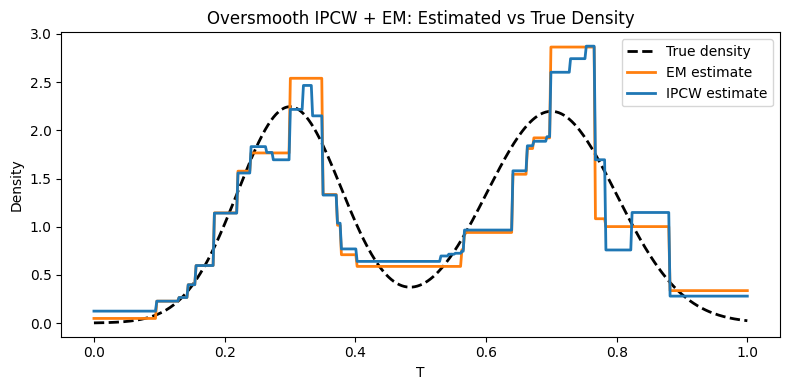

In [13]:
# Plot estimated vs true density
grid = np.linspace(0, 1, 500)
true_pdf = event_dgp.compute_density(grid)
est_em_pdf = best_em_estimator.get_density_at_points(grid)
est_ipcw_pdf = best_ipcw_estimator.get_density_at_points(grid)
plt.figure(figsize=(8, 4))
plt.plot(grid, true_pdf, "k--", lw=2, label="True density")
plt.plot(grid, est_em_pdf, "C1-", lw=2, label="EM estimate")
plt.plot(grid, est_ipcw_pdf, "C0-", lw=2, label="IPCW estimate")
plt.xlabel("T")
plt.ylabel("Density")
plt.title("Oversmooth IPCW + EM: Estimated vs True Density")
plt.legend()
plt.tight_layout()
plt.show()

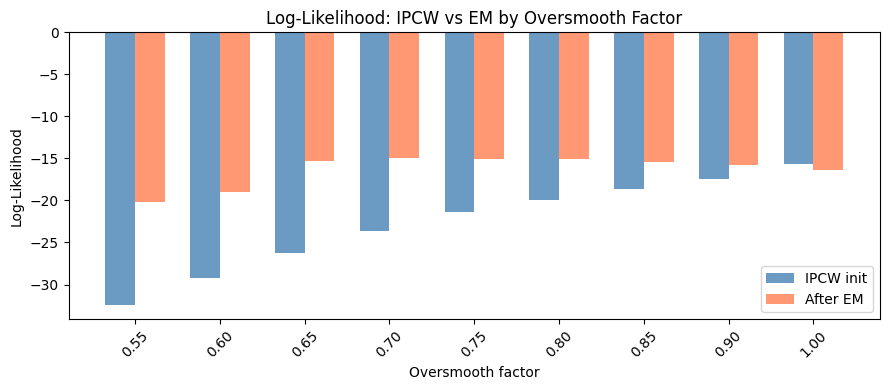

In [14]:
# Bar chart: IPCW LL vs EM LL by factor
import pandas as pd

df = pd.DataFrame(records)
x = np.arange(len(df))
width = 0.35

fig, ax = plt.subplots(figsize=(9, 4))
ax.bar(x - width/2, df["ipcw_ll"], width, label="IPCW init", color="steelblue", alpha=0.8)
ax.bar(x + width/2, df["em_ll"], width, label="After EM", color="coral", alpha=0.8)
ax.set_xticks(x)
ax.set_xticklabels([f"{f:.2f}" for f in df["factor"]], rotation=45)
ax.set_xlabel("Oversmooth factor")
ax.set_ylabel("Log-Likelihood")
ax.legend()
ax.set_title("Log-Likelihood: IPCW vs EM by Oversmooth Factor")
plt.tight_layout()
plt.show()

## Summary

- **Conservative CV** finds a smaller `λ*` than raw Optuna, reducing model complexity.
- **Oversmooth exploration** fits IPCW inits with `factor × λ*`; smaller factors → fewer knots.
- **Forward grid selection** picks the largest factor for each unique (smaller) knot count.
- **EM refinement** runs once per candidate (no CV), updating coefficients while keeping knots fixed.
- The tuner returns the **best EM estimator** by incomplete log-likelihood.